<a href="https://colab.research.google.com/github/elireinhold/CS-584-Final-Project/blob/main/context_model_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rouge_score
from google.colab import drive
SAVE_PATH = "/content/drive/MyDrive/prompt_predictor_v3"

In [3]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import T5ForConditionalGeneration, T5Tokenizer
from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer
import numpy as np
import re

### Load Data

In this version, we filtered the data to eliminate things the model struggled with:
1. Code heavy answers
2. Long complex prompts or answers
3. Very short promprts or answers

In [4]:
df = pd.read_csv("prompt_answer_pairs_clean.csv")
print(f"Original: {len(df)} rows")

# 1. Filter rows where answer is mostly code blocks to remove blocks
def clean_answer(text):
    text = re.sub(r'\[CODE_BLOCK_\d+\]', '', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["answer"] = df["answer"].apply(clean_answer)
print(f"After code block filter: {len(df)} rows")

# 2. Drop rows where answer became too short after removing code blocks
df = df[df["answer"].str.split().str.len() >= 10]
print(f"After dropping short answers: {len(df)} rows")

# 3. Filter out very long prompts (over 50 words)
df = df[df["prompt"].str.split().str.len() <= 50]
print(f"After long prompt filter: {len(df)} rows")

# 4. Filter out very short prompts (less than 3 words)
df = df[df["prompt"].str.split().str.len() >= 3]
print(f"After short prompt filter: {len(df)} rows")

# 5. Filter out very long answers (over 400 words)
df = df[df["answer"].str.split().str.len() <= 400]
print(f"After long answer filter: {len(df)} rows")

df.to_csv("prompt_answer_pairs_filtered.csv", index=False, encoding="utf-8")

Original: 8058 rows
After code block filter: 8058 rows
After dropping short answers: 7509 rows
After long prompt filter: 4650 rows
After short prompt filter: 4621 rows
After long answer filter: 4315 rows


In this version we build context, building history from the prior turns

In [5]:
def build_context_input(group):
    rows = group.reset_index(drop=True)
    context_inputs = []

    for i, row in rows.iterrows():
        # Only use last 2 prior turns
        history = ""
        start = max(0, i - 2)
        # Build history by appending previous
        for j in range(start, i):
            prev = rows.iloc[j]
            history += f"User: {prev['prompt']} Assistant: {prev['answer']} "

        # If there is a history prepend it, if not just use answer
        if history:
            context_input = f"predict prompt: {history.strip()} Current answer: {row['answer']}"
        else:
            context_input = f"predict prompt: {row['answer']}"

        context_inputs.append(context_input)

    group = group.copy()
    group["context_input"] = context_inputs
    return group

# Splits df into groups by conversation url and then applys the context function independently
df = df.sort_values(["chatgpt_url", "conv_index"]).reset_index(drop=True)
df = df.groupby("chatgpt_url", group_keys=False).apply(build_context_input)

df.to_csv("prompt_answer_pairs_context.csv", index=False, encoding="utf-8")

/tmp/ipykernel_5484/720515632.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("chatgpt_url", group_keys=False).apply(build_context_input)


In [6]:
df = pd.read_csv("prompt_answer_pairs_context.csv")[["context_input", "prompt", "answer"]].dropna()

# Convert to strings
df["prompt"] = df["prompt"].astype(str).str.strip()
df["answer"] = df["answer"].astype(str).str.strip()
df["context_input"] = df["context_input"].astype(str).str.strip()

# 70/15/15
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

### Tokenize data

In [7]:
def tokenize_data(df):
  # Input is the answer, tokenizes answer text
  inputs = tokenizer(
      df["context_input"].tolist(),
      max_length=512,
      padding="max_length",
      truncation=True,
      return_tensors="pt"
    )
  # Target is the prompt, tokenizes prompt text
  targets = tokenizer(
      df["prompt"].tolist(),
      max_length=128,
      padding="max_length",
      truncation=True,
      return_tensors="pt"
  )

  labels = targets["input_ids"]
  # Replace padding tokens with -100 so model does not try to predict them
  labels[labels == tokenizer.pad_token_id] = -100

  # Create tokenized dataset
  dataset = torch.utils.data.TensorDataset(
      inputs["input_ids"],
      inputs["attention_mask"],
      labels
  )
  return dataset

In [8]:
# Load tokenizer
tokenizer = T5Tokenizer.from_pretrained("t5-small")
# Model is a T5 language model
# T5 is a seq2seq model that is pretrained using a  using a denoising objective
model     = T5ForConditionalGeneration.from_pretrained("t5-small").to(torch.device("cuda"))

# Tokenize all datasets
train_dataset = tokenize_data(train_df)
val_dataset   = tokenize_data(val_df)
test_dataset  = tokenize_data(test_df)

# DataLoader does batching, shuffling and makes dataset iterable
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

### Evaluate how model is doing on validation set

In [9]:
def evaluate(loader):
  # Switch model to evaluation mode
  model.eval()
  total_loss = 0
  # Do not track gradients to save memory
  with torch.no_grad():
    # For every batch accumulate the loss
    for batch in loader:
        input_ids, attention_mask, labels = batch
        input_ids      = input_ids.to(torch.device("cuda"))
        attention_mask = attention_mask.to(torch.device("cuda"))
        labels         = labels.to(torch.device("cuda"))
        loss = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels).loss
        total_loss += loss.item()
  # Return the average loss per epoch
  return total_loss / len(loader)

### Train Model

In this verision I added early stopping which stops training automatically when the validation loss stops improving to prevent overfitting. I did this instead of only doing 5 epochs like before to help model learn dataset better.

In [11]:
# Load optimizer
optimizer   = torch.optim.AdamW(model.parameters(), lr=5e-5)
best_val    = float("inf")

# Early stopping settings
patience = 3 # how many epochs to wait before stopping
epochs_no_improve = 0
epoch = 0

while True:
  epoch += 1
  # Switch model to train mode
  model.train()
  total_train_loss = 0

  for i, batch in enumerate(train_loader):
    input_ids, attention_mask, labels = batch
    input_ids      = input_ids.to(torch.device("cuda"))
    attention_mask = attention_mask.to(torch.device("cuda"))
    labels         = labels.to(torch.device("cuda"))

    # Clear gradient from previous batch
    optimizer.zero_grad()
    # Calculates loss using T5 model
    loss = model(input_ids=input_ids,
                  attention_mask=attention_mask,
                  labels=labels).loss
    # Backpropagation
    loss.backward()
    # Gradient clipping (caps gradients at 1)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    # Updates model weights using gradients calculated by loss.backward
    optimizer.step()

    total_train_loss += loss.item()

    if (i + 1) % 50 == 0:
      print(f"  Epoch {epoch} | Step {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

  avg_train = total_train_loss / len(train_loader)
  avg_val   = evaluate(val_loader)
  print(f"\nEpoch {epoch} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

  # Gets best model by updating model saved when average validation loss is less
  if avg_val < best_val:
    best_val = avg_val
    model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
  # Break out of loop when no model improvement for 3 epochs in a row
  else:
    epochs_no_improve += 1
    if epochs_no_improve >= patience:
      print(f"\nEarly stopping triggered after {epoch} epochs")
      break

  Epoch 1 | Step 50/378 | Loss: 3.5333
  Epoch 1 | Step 100/378 | Loss: 3.8087
  Epoch 1 | Step 150/378 | Loss: 3.5256
  Epoch 1 | Step 200/378 | Loss: 2.7163
  Epoch 1 | Step 250/378 | Loss: 3.2300
  Epoch 1 | Step 300/378 | Loss: 3.1458
  Epoch 1 | Step 350/378 | Loss: 1.8104

Epoch 1 | Train Loss: 3.3930 | Val Loss: 3.2099


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 2 | Step 50/378 | Loss: 3.4782
  Epoch 2 | Step 100/378 | Loss: 3.4136
  Epoch 2 | Step 150/378 | Loss: 3.5294
  Epoch 2 | Step 200/378 | Loss: 3.0201
  Epoch 2 | Step 250/378 | Loss: 3.3049
  Epoch 2 | Step 300/378 | Loss: 4.0073
  Epoch 2 | Step 350/378 | Loss: 3.7618

Epoch 2 | Train Loss: 3.2527 | Val Loss: 3.1546


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 3 | Step 50/378 | Loss: 2.6987
  Epoch 3 | Step 100/378 | Loss: 3.5651
  Epoch 3 | Step 150/378 | Loss: 3.2039
  Epoch 3 | Step 200/378 | Loss: 3.3443
  Epoch 3 | Step 250/378 | Loss: 3.2986
  Epoch 3 | Step 300/378 | Loss: 3.5370
  Epoch 3 | Step 350/378 | Loss: 3.7644

Epoch 3 | Train Loss: 3.1757 | Val Loss: 3.1175


...

  Epoch 7 | Step 50/378 | Loss: 2.6513
  Epoch 7 | Step 100/378 | Loss: 3.1629
  Epoch 7 | Step 150/378 | Loss: 3.6817
  Epoch 7 | Step 200/378 | Loss: 3.1401
  Epoch 7 | Step 250/378 | Loss: 2.8567
  Epoch 7 | Step 300/378 | Loss: 3.0034
  Epoch 7 | Step 350/378 | Loss: 2.3885

Epoch 7 | Train Loss: 2.9380 | Val Loss: 3.0680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 8 | Step 50/378 | Loss: 2.7357
  Epoch 8 | Step 100/378 | Loss: 2.8951
  Epoch 8 | Step 150/378 | Loss: 3.0087
  Epoch 8 | Step 200/378 | Loss: 2.3962
  Epoch 8 | Step 250/378 | Loss: 3.5360
  Epoch 8 | Step 300/378 | Loss: 2.7380
  Epoch 8 | Step 350/378 | Loss: 3.1977

Epoch 8 | Train Loss: 2.8894 | Val Loss: 3.0711
  Epoch 9 | Step 50/378 | Loss: 3.7309
  Epoch 9 | Step 100/378 | Loss: 2.5251
  Epoch 9 | Step 150/378 | Loss: 2.7603
  Epoch 9 | Step 200/378 | Loss: 3.0863
  Epoch 9 | Step 250/378 | Loss: 2.9826
  Epoch 9 | Step 300/378 | Loss: 3.9462
  Epoch 9 | Step 350/378 | Loss: 3.1250

Epoch 9 | Train Loss: 2.8574 | Val Loss: 3.0607


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 10 | Step 50/378 | Loss: 2.6697
  Epoch 10 | Step 100/378 | Loss: 2.8265
  Epoch 10 | Step 150/378 | Loss: 2.3015
  Epoch 10 | Step 200/378 | Loss: 2.7957
  Epoch 10 | Step 250/378 | Loss: 2.8908
  Epoch 10 | Step 300/378 | Loss: 2.5725
  Epoch 10 | Step 350/378 | Loss: 3.1853

Epoch 10 | Train Loss: 2.8026 | Val Loss: 3.0640
  Epoch 11 | Step 50/378 | Loss: 2.8749
  Epoch 11 | Step 100/378 | Loss: 2.6400
  Epoch 11 | Step 150/378 | Loss: 3.0885
  Epoch 11 | Step 200/378 | Loss: 3.0283
  Epoch 11 | Step 250/378 | Loss: 2.3966
  Epoch 11 | Step 300/378 | Loss: 2.3467
  Epoch 11 | Step 350/378 | Loss: 2.8749

Epoch 11 | Train Loss: 2.7800 | Val Loss: 3.0684

Early stopping triggered after 11 epochs


### Evaulate Model Performace with ROUGE
ROUGE is a metric that measures how simular predicted prompt is to real prompt by comparing n-gram overlap

- ROUGE-1: Counts overlap of individual words
- ROUGE-2: Counts overlap of word pairs
- ROUGE-L: Finds longest common sequence of words in order

In [12]:
model = T5ForConditionalGeneration.from_pretrained(SAVE_PATH).to(torch.device("cuda"))
model.eval()

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
r1, r2, rL = [], [], []

for _, row in test_df.iterrows():
    # Tokenize input
    input_text = row["context_input"]
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(torch.device("cuda"))

    # Generate prediction
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )

    # Decode prediction back to text
    predicted = tokenizer.decode(output[0], skip_special_tokens=True)

    # Score predicted vs real prompt
    scores = scorer.score(row["prompt"], predicted)
    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rL.append(scores["rougeL"].fmeasure)

# Print results
print(f"ROUGE-1:  {np.mean(r1):.4f}")
print(f"ROUGE-2:  {np.mean(r2):.4f}")
print(f"ROUGE-L:  {np.mean(rL):.4f}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

ROUGE-1:  0.3093
ROUGE-2:  0.1522
ROUGE-L:  0.2705


### Sample Predictions

In [15]:
results = []
for _, row in test_df.iterrows():
    input_text = row["context_input"]
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(torch.device("cuda"))

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=128,
            num_beams=4,
            early_stopping=True
        )

    predicted = tokenizer.decode(output[0], skip_special_tokens=True)
    rouge_l_score   = scorer.score(row["prompt"], predicted)["rougeL"].fmeasure

    results.append({
        "prompt": row["answer"],
        "reference":  row["prompt"],
        "prediction": predicted,
        "rouge_l": rouge_l_score
    })

results_df = pd.DataFrame(results)

# Sort by rouge_l to see best and worst predictions
results_df = results_df.sort_values("rouge_l", ascending=False).reset_index(drop=True)

# Save results to predictions.csv which contains real prompt, predicted prompt, answer, ROUGE-L
# The line below is now redundant as 'rouge_l' is already calculated and added
# results_df["rouge_l"] = [
#     scorer.score(r["reference"], r["prediction"])["rougeL"].fmeasure
#     for r in results]
results_df.to_csv("predictions_v3.csv", index=False, encoding="utf-8")
print(f"Saved {len(results_df)} predictions to predictions.csv")
print(f"\nBest ROUGE-L:  {results_df['rouge_l'].max():.4f}")
print(f"Worst ROUGE-L: {results_df['rouge_l'].min():.4f}")
print(f"Mean ROUGE-L:  {results_df['rouge_l'].mean():.4f}")

Saved 648 predictions to predictions.csv

Best ROUGE-L:  1.0000
Worst ROUGE-L: 0.0000
Mean ROUGE-L:  0.2705


Comparing ROUGE-L of prompts which include coding and prompts which include no coding

In [16]:
# Split test set into code and non-code prompts
code_pattern = r'def |class |import |\bif\b|\bfor\b|\bwhile\b|{|}|=>|!=|=='

code_df    = test_df[test_df["prompt"].str.contains(code_pattern, regex=True)]
no_code_df = test_df[~test_df["prompt"].str.contains(code_pattern, regex=True)]

print(f"Code prompts:    {len(code_df)} rows")
print(f"Non-code prompts: {len(no_code_df)} rows")

Code prompts:    188 rows
Non-code prompts: 460 rows


In [18]:
def get_rouge_l(df):
    scores = []
    for _, row in df.iterrows():
        input_text = row["context_input"]
        inputs = tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(torch.device("cuda"))

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_length=128,
                num_beams=4,
                early_stopping=True
            )

        predicted = tokenizer.decode(output[0], skip_special_tokens=True)
        score = scorer.score(row["prompt"], predicted)
        scores.append(score["rougeL"].fmeasure)
    return scores

code_scores    = get_rouge_l(code_df)
no_code_scores = get_rouge_l(no_code_df)

print(f"Code prompts:     {np.mean(code_scores):.4f}")
print(f"Non-code prompts: {np.mean(no_code_scores):.4f}")
print(f"Overall:          {np.mean(code_scores + no_code_scores):.4f}")

Code prompts:     0.2398
Non-code prompts: 0.2830
Overall:          0.2705


      model_name  rows  exact_match  token_f1  prediction_tokens  reference_tokens  length_ratio  prediction_has_code  reference_has_code  rouge1  rouge2  rougeL
context_model_v3   648       0.0062    0.2942            12.6605            20.034        0.9541               0.0247              0.1096  0.3093  0.1522  0.2705

Saved summary to model_comparison_summary.csv
Saved detailed report to model_comparison_details.json


--- Generating Visualizations ---


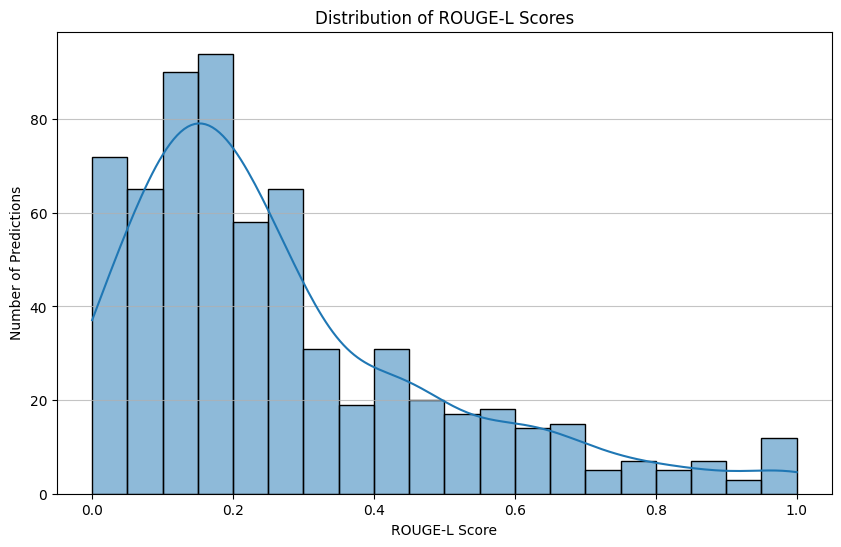


--- Sample Predictions (Best, Average, Worst) ---

Best ROUGE-L Score: 1.0000
  Reference Prompt: What is a Master Bill of Lading
  Predicted Prompt: What is a Master Bill of Lading?
  Original Answer:  A Master Bill of Lading (MBL) is a legal shipping document issued by the carrier or freight forwarder. It serves as a contract of carriage and receipt of goods for international shipments involving multiple parties, such as freight forwarders, consolidators, and shipping lines.The MBL is typically issued by the shipping line or the carrier responsible for the main transport leg of the shipment. It outlines the terms and conditions of the transportation contract and includes important information such as the names and addresses of the shipper, consignee, and carrier, as well as details about the goods being shipped.One key feature of the MBL is that it covers the entire shipment from the port of origin to the final destination. It acts as a master document that governs the relationship 

In [22]:
import argparse
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from rouge_score import rouge_scorer
except ImportError:
    rouge_scorer = None


CODE_PATTERN = re.compile(
    r"(```|`[^`]+`|\bdef\b|\bclass\b|\bimport\b|#include|SELECT\s+.+\s+FROM)",
    flags=re.IGNORECASE | re.DOTALL,
)

MODEL_NAME_ALIASES = {
    "predictions_v3": "context_model_v3",
    "context_model_predictions": "context_model_v3",
    "filtered_model_predictions": "filtered_model_v2",
    "initial_model_predictions": "initial_model_v1",
}


def parse_args():
    parser = argparse.ArgumentParser(
        description="Compare model prediction files on one shared evaluation set."
    )
    parser.add_argument(
        "--predictions",
        nargs="*",
        default=["predictions_v3.csv"],
        help="CSV files containing at least: prompt, reference, prediction.",
    )
    parser.add_argument(
        "--output-csv",
        default="model_comparison_summary.csv",
        help="Where to save the aggregate comparison table.",
    )
    parser.add_argument(
        "--output-json",
        default="model_comparison_details.json",
        help="Where to save bucketed metrics and config details.",
    )
    return parser.parse_args()


def normalize_columns(df):
    rename_map = {}
    for column in df.columns:
        lower = column.strip().lower()
        if lower in {"answer", "target", "gold", "label"}:
            rename_map[column] = "reference"
        elif lower in {"output", "predicted", "predicted_prompt", "generated_text", "response"}:
            rename_map[column] = "prediction"
        elif lower in {"input"}:
            rename_map[column] = "prompt"

    df = df.rename(columns=rename_map)
    required = {"prompt", "reference", "prediction"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    return df[list(required)].copy()


def token_set(text):
    return re.findall(r"\w+", str(text).lower())


def token_f1(reference, prediction):
    ref_tokens = token_set(reference)
    pred_tokens = token_set(prediction)

    if not ref_tokens and not pred_tokens:
        return 1.0
    if not ref_tokens or not pred_tokens:
        return 0.0

    ref_counts = {}
    pred_counts = {}
    for token in ref_tokens:
        ref_counts[token] = ref_counts.get(token, 0) + 1
    for token in pred_tokens:
        pred_counts[token] = pred_counts.get(token, 0) + 1

    overlap = 0
    for token, count in ref_counts.items():
        overlap += min(count, pred_counts.get(token, 0))

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def exact_match(reference, prediction):
    return float(str(reference).strip() == str(prediction).strip())


def has_code(text):
    return bool(CODE_PATTERN.search(str(text)))


def prompt_bucket(prompt):
    tokens = token_set(prompt)
    length = len(tokens)

    if has_code(prompt):
        return "code_prompt"
    if length <= 8:
        return "short_prompt"
    if length >= 25:
        return "long_prompt"
    return "medium_prompt"


def build_scorer():
    if rouge_scorer is None:
        return None
    return rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


def score_row(reference, prediction, scorer):
    metrics = {
        "exact_match": exact_match(reference, prediction),
        "token_f1": token_f1(reference, prediction),
        "prediction_tokens": len(token_set(prediction)),
        "reference_tokens": len(token_set(reference)),
        "length_ratio": (
            len(token_set(prediction)) / len(token_set(reference))
            if len(token_set(reference)) > 0
            else 0.0
        ),
        "prediction_has_code": float(has_code(prediction)),
        "reference_has_code": float(has_code(reference)),
    }

    if scorer is not None:
        rouge_scores = scorer.score(str(reference), str(prediction))
        metrics["rouge1"] = rouge_scores["rouge1"].fmeasure
        metrics["rouge2"] = rouge_scores["rouge2"].fmeasure
        metrics["rougeL"] = rouge_scores["rougeL"].fmeasure

    return metrics


def aggregate_metrics(df, metric_columns):
    summary = df[metric_columns].mean().to_dict()
    return {key: round(float(value), 4) for key, value in summary.items()}


def infer_model_name(path):
    stem = Path(path).stem
    return MODEL_NAME_ALIASES.get(stem, stem)


def compare_file(path, scorer):
    csv_path = Path(path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Prediction file not found: {path}. "
            "Export predictions from each notebook first, then pass those CSV files here."
        )

    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    df = df.dropna(subset=["prompt", "reference", "prediction"]).reset_index(drop=True)
    df["bucket"] = df["prompt"].apply(prompt_bucket)

    metric_rows = []
    for row in df.itertuples(index=False):
        metrics = score_row(row.reference, row.prediction, scorer)
        metric_rows.append(metrics)

    metrics_df = pd.DataFrame(metric_rows)
    combined = pd.concat([df, metrics_df], axis=1)

    metric_columns = list(metrics_df.columns)
    overall = aggregate_metrics(combined, metric_columns)

    buckets = {}
    for bucket_name, bucket_df in combined.groupby("bucket"):
        buckets[bucket_name] = {
            "rows": int(len(bucket_df)),
            "metrics": aggregate_metrics(bucket_df, metric_columns),
        }

    return {
        "model_name": infer_model_name(path),
        "rows": int(len(combined)),
        "metrics": overall,
        "buckets": buckets,
    }


def main():
    args = parse_args()
    scorer = build_scorer()

    reports = []
    # Pass args.predictions as a list to compare_file
    for path in args.predictions if isinstance(args.predictions, list) else [args.predictions]:
        report = compare_file(path, scorer)
        reports.append(report)

    if not reports:
        raise ValueError("No prediction reports were generated.")

    summary_rows = []
    for report in reports:
        row = {"model_name": report["model_name"], "rows": report["rows"]}
        row.update(report["metrics"])
        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows).sort_values(
        by="rougeL" if "rougeL" in summary_rows[0] else "token_f1",
        ascending=False,
    )
    summary_df.to_csv(args.output_csv, index=False)

    details = {
        "used_rouge_score": scorer is not None,
        "reports": reports,
    }
    with open(args.output_json, "w", encoding="utf-8") as handle:
        json.dump(details, handle, indent=2)

    print(summary_df.to_string(index=False))
    print(f"\nSaved summary to {args.output_csv}")
    print(f"Saved detailed report to {args.output_json}")


if __name__ == "__main__":
    # Simulate command-line arguments for notebook execution
    import sys
    sys.argv = ['colab_kernel_launcher.py', '--predictions', 'predictions_v3.csv']
    main()

    # Visualization code
    print("\n\n--- Generating Visualizations ---")
    predictions_df = pd.read_csv("predictions_v3.csv")

    # Histogram of ROUGE-L scores
    plt.figure(figsize=(10, 6))
    sns.histplot(predictions_df['rouge_l'], bins=20, kde=True)
    plt.title('Distribution of ROUGE-L Scores')
    plt.xlabel('ROUGE-L Score')
    plt.ylabel('Number of Predictions')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Display examples of predictions
    print("\n--- Sample Predictions (Best, Average, Worst) ---")

    # Best prediction
    best_pred = predictions_df.sort_values(by='rouge_l', ascending=False).iloc[0]
    print(f"\nBest ROUGE-L Score: {best_pred['rouge_l']:.4f}")
    print(f"  Reference Prompt: {best_pred['reference']}")
    print(f"  Predicted Prompt: {best_pred['prediction']}")
    print(f"  Original Answer:  {best_pred['prompt']}")

    # Average prediction (closest to mean)
    mean_rouge_l = predictions_df['rouge_l'].mean()
    avg_pred_index = (predictions_df['rouge_l'] - mean_rouge_l).abs().argsort()[:1].iloc[0]
    avg_pred = predictions_df.iloc[avg_pred_index]
    print(f"\nAverage ROUGE-L Score (closest to mean {mean_rouge_l:.4f}): {avg_pred['rouge_l']:.4f}")
    print(f"  Reference Prompt: {avg_pred['reference']}")
    print(f"  Predicted Prompt: {avg_pred['prediction']}")
    print(f"  Original Answer:  {avg_pred['prompt']}")

    # Worst prediction
    worst_pred = predictions_df.sort_values(by='rouge_l', ascending=True).iloc[0]
    print(f"\nWorst ROUGE-L Score: {worst_pred['rouge_l']:.4f}")
    print(f"  Reference Prompt: {worst_pred['reference']}")
    print(f"  Predicted Prompt: {worst_pred['prediction']}")
    print(f"  Original Answer:  {worst_pred['prompt']}")


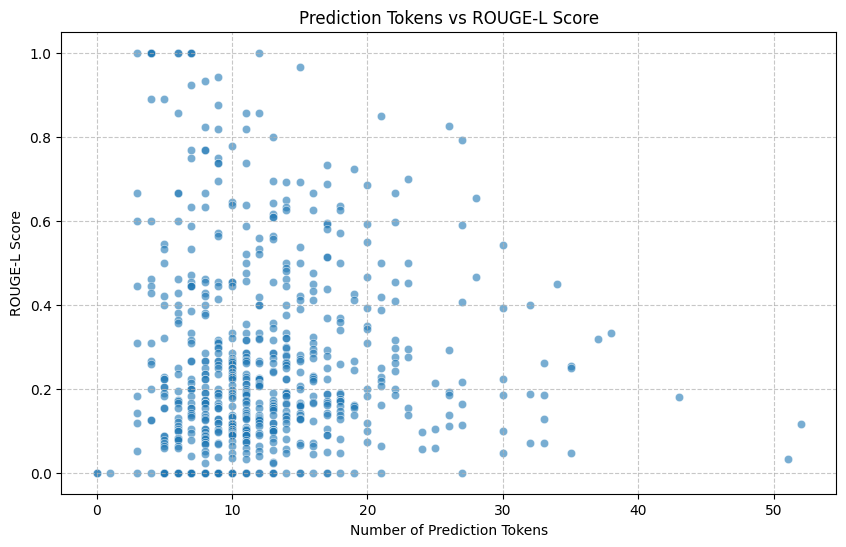

In [24]:
# Ensure 'prediction_tokens' is available in predictions_df
# The token_set function is defined in a previous cell (ZiLCltJOpyOG).
# If this cell is run independently, predictions_df might need to be reloaded
# and token_set imported or redefined.

# Assuming token_set is available from the previously run cell ZiLCltJOpyOG
def token_set(text):
    return re.findall(r"\w+", str(text).lower())

predictions_df['prediction_tokens'] = predictions_df['prediction'].apply(lambda x: len(token_set(x)))

plt.figure(figsize=(10, 6))
sns.scatterplot(x='prediction_tokens', y='rouge_l', data=predictions_df, alpha=0.6)
plt.title('Prediction Tokens vs ROUGE-L Score')
plt.xlabel('Number of Prediction Tokens')
plt.ylabel('ROUGE-L Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Analyzing Empty and Low-Scoring Predictions

In [25]:
import numpy as np

# Filter for predictions where the 'prediction' column is empty or has a very low ROUGE-L score.
# An empty string prediction would result in a ROUGE-L score of 0.0.
empty_or_low_rouge_preds = predictions_df[
    (predictions_df['prediction'].str.strip() == '') | (predictions_df['rouge_l'] <= 0.01)
]

print(f"Found {len(empty_or_low_rouge_preds)} predictions with empty or very low ROUGE-L scores.\n")

if not empty_or_low_rouge_preds.empty:
    print("Examples of empty/low-scoring predictions:")
    for i, row in empty_or_low_rouge_preds.head(10).iterrows():
        print(f"-- Sample {i+1} --")
        print(f"  Context Input: {row['prompt']}") # This is the original 'answer' which serves as context
        print(f"  Reference Prompt: {row['reference']}")
        print(f"  Predicted Prompt: '{row['prediction']}'") # Quoting to show empty string clearly
        print(f"  ROUGE-L Score: {row['rouge_l']:.4f}")
        print("---------------------")
else:
    print("No predictions found with empty or very low ROUGE-L scores.")

Found 54 predictions with empty or very low ROUGE-L scores.

Examples of empty/low-scoring predictions:
-- Sample 595 --
  Context Input: When building a search engine, the choice of query language depends on various factors such as the complexity of your search requirements, the type of data you're searching, and the features you want to support. Here are a few popular query languages commonly used in search engines:SQL (Structured Query Language): SQL is a widely used query language for relational databases. If your search engine is built on a relational database system, SQL can be a suitable option. It allows you to write powerful queries using conditions, joins, aggregations, and sorting.Elasticsearch Query DSL: Elasticsearch is a popular search engine that provides a powerful query language called Elasticsearch Query DSL. It offers a JSON-based syntax for constructing complex search queries. Elasticsearch is known for its full-text search capabilities, relevance scoring, and suppo

### Best and Worst Predicted Prompts

In [27]:
import pandas as pd

# Set display option to show full column width
pd.set_option('display.max_colwidth', None)

# Display the 10 best predicted prompts
print("\n--- 10 Best Predicted Prompts ---")
display(predictions_df.head(10)[['reference', 'prediction', 'rouge_l']])

# Display the 5 worst predicted prompts
print("\n--- 5 Worst Predicted Prompts ---")
display(predictions_df.tail(5)[['reference', 'prediction', 'rouge_l']])

# Reset display option to default if needed later (optional)
pd.reset_option('display.max_colwidth')


--- 10 Best Predicted Prompts ---


,reference,prediction,rouge_l
0,What is Carrier Performance?,What is Carrier Performance?,1.0
1,What is a Master Bill of Lading,What is a Master Bill of Lading?,1.0
2,What is a Freight Handling Unit,What is a Freight Handling Unit?,1.0
3,What is a Terminal in freight logistics?,What is a terminal in freight logistics?,1.0
4,How do I add something to the clipboard in a react app,How do I add something to the clipboard in a React app,1.0
5,what is Rss,What is RSS?,1.0
6,What is EDI 214,What is EDI 214?,1.0
7,What is Freight Packaging?,What is Freight Packaging?,1.0
8,What is a Third Party Logistics Provider?,What is a Third Party Logistics Provider?,1.0
9,What is EDI 940?,What is EDI 940?,1.0



--- 5 Worst Predicted Prompts ---


,reference,prediction,rouge_l
643,what's different about this than the last one you just gave me?,i think Round and Match are redundant,0.0
644,What are the possible values for $interval?,Can I use wp_schedule_single_event to run recurring actions?,0.0
645,AliensBreeding.slncan you check that this runs?,"I have a "".sln"" extension, which indicates it is a solution file used by Microsoft Visual Studio",0.0
646,Can You give one practical example of all 4,write this code with prepared statement,0.0
647,That was wrong. What happened?,,0.0
